# Random Forest
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn import tree
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.discriminant_analysis import StandardScaler

---------------

## Helpfull Code

------------------------

## Load Data

In [42]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [66]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])
x_copy = x.copy()
scaler = StandardScaler()
x = scaler.fit_transform(x)

## Train-Test Split

In [44]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## בדיקת ערכי ההייפר פרמטרים

In [46]:
results = []
best_score = -1
best_params_rf = {}

#### n_estimators

In [47]:
results_n = []
best_score_n = 0
best_n = None

for n in range(50, 800, 50):

    rf = RFC(
        random_state=42,
        n_estimators=n,
        max_depth=None
    )

    fold_scores = cross_val_score(
        rf,
        x_train, y_train,
        cv=cv,
        scoring="accuracy"
    )

    mean_score = fold_scores.mean()

    results_n.append({
        "n_estimators": n,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    print(f"n_estimators: {n}, CV Accuracy: {100*mean_score:.2f}%")
    if mean_score > best_score_n:
        best_score_n = mean_score
        best_n = n

print("Best n_estimators:", best_n)
print(f"Best CV accuracy: {100*best_score_n:.2f}%")

results_n_df = pd.DataFrame(results_n).sort_values("cv_mean", ascending=False)
display(results_n_df.head(10).round(4))

n_estimators: 50, CV Accuracy: 79.77%
n_estimators: 100, CV Accuracy: 79.83%
n_estimators: 150, CV Accuracy: 79.71%
n_estimators: 200, CV Accuracy: 79.80%
n_estimators: 250, CV Accuracy: 79.96%
n_estimators: 300, CV Accuracy: 79.92%
n_estimators: 350, CV Accuracy: 79.83%
n_estimators: 400, CV Accuracy: 79.86%
n_estimators: 450, CV Accuracy: 79.85%
n_estimators: 500, CV Accuracy: 79.86%
n_estimators: 550, CV Accuracy: 79.82%
n_estimators: 600, CV Accuracy: 79.82%
n_estimators: 650, CV Accuracy: 79.71%
n_estimators: 700, CV Accuracy: 79.67%
n_estimators: 750, CV Accuracy: 79.70%
Best n_estimators: 250
Best CV accuracy: 79.96%


,n_estimators,cv_mean,cv_std
4,250,0.7996,0.0067
5,300,0.7992,0.0069
7,400,0.7986,0.0086
9,500,0.7986,0.0085
8,450,0.7985,0.0078
6,350,0.7983,0.0075
1,100,0.7983,0.0066
11,600,0.7982,0.0084
10,550,0.7982,0.0078
3,200,0.7980,0.0070


#### max_depth

In [48]:
results_depth = []
best_score_depth = 0
best_depth = None

for depth in range(5, 25):

    rf = RFC(
        random_state=42,
        n_estimators=best_n,
        max_depth=depth
    )

    fold_scores = cross_val_score(
        rf,
        x_train, y_train,
        cv=cv,
        scoring="accuracy"
    )

    mean_score = fold_scores.mean()

    results_depth.append({
        "max_depth": depth,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })
    
    if mean_score > best_score_depth:
        best_score_depth = mean_score
        best_depth = depth

print("Best max_depth:", best_depth)
print(f"Best CV accuracy: {100*best_score_depth:.2f}%")

results_depth_df = pd.DataFrame(results_depth).sort_values("cv_mean", ascending=False)
display(results_depth_df.head(10).round(4))

Best max_depth: 21
Best CV accuracy: 79.87%


,max_depth,cv_mean,cv_std
16,21,0.7987,0.0069
17,22,0.7980,0.0071
10,15,0.7979,0.0038
18,23,0.7974,0.0090
19,24,0.7974,0.0081
8,13,0.7967,0.0043
11,16,0.7967,0.0019
12,17,0.7967,0.0042
9,14,0.7964,0.0047
15,20,0.7964,0.0067


#### max_features

In [49]:
results_feat = []
best_score_final = 0
best_params_rf = None

for feat in ["sqrt", "log2", None]:

    rf = RFC(
        random_state=42,
        n_estimators=best_n,
        max_depth=best_depth,
        max_features=feat
    )

    fold_scores = cross_val_score(
        rf,
        x_train, y_train,
        cv=cv,
        scoring="accuracy"
    )

    mean_score = fold_scores.mean()

    results_feat.append({
        "max_features": feat,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })    
    if mean_score > best_score_final:
        best_score_final = mean_score
        best_params_rf = {
            "n_estimators": best_n,
            "max_depth": best_depth,
            "max_features": feat
        }

print("\nBest RF params:", best_params_rf)
print(f"Best CV accuracy: {100*best_score_final:.2f}%")

results_feat_df = pd.DataFrame(results_feat).sort_values("cv_mean", ascending=False)
display(results_feat_df.round(4))



Best RF params: {'n_estimators': 250, 'max_depth': 21, 'max_features': 'sqrt'}
Best CV accuracy: 79.87%


,max_features,cv_mean,cv_std
0,sqrt,0.7987,0.0069
1,log2,0.7987,0.0069
2,None,0.7882,0.0061


#### min_sample_leaf

In [50]:
results_leaf = []

best_score = 0
best_leaf = None

for leaf in range(5, 31, 1):

    rf = RFC(
        random_state=42,
        n_estimators=best_params_rf["n_estimators"],
        max_depth=best_params_rf["max_depth"],
        max_features=best_params_rf["max_features"],
        min_samples_leaf=leaf
    )

    scores = cross_val_score(
        rf,
        x_train, y_train,
        cv=cv,
        scoring="accuracy"
    )

    mean_score = scores.mean()

    results_leaf.append({
        "min_samples_leaf": leaf,
        "cv_mean": mean_score,
        "cv_std": scores.std()
    })

    if mean_score > best_score:
        best_score = mean_score
        best_leaf = leaf

print("Best min_samples_leaf:", best_leaf)
print(f"Best CV accuracy: {100*best_score:.2f}%")

display(pd.DataFrame(results_leaf).sort_values("cv_mean", ascending=False).round(4))

Best min_samples_leaf: 7
Best CV accuracy: 79.76%


,min_samples_leaf,cv_mean,cv_std
2,7,0.7976,0.0043
3,8,0.7974,0.0072
0,5,0.7963,0.0047
1,6,0.7961,0.0062
4,9,0.7952,0.0059
5,10,0.7951,0.0067
8,13,0.7941,0.0068
6,11,0.7941,0.0063
14,19,0.7933,0.0098
11,16,0.7933,0.0079


## run best Random Forest

In [77]:
# יצירת טבלת הייפר-פרמטרים
rf_params_table = pd.DataFrame({
    "Hyperparameter": [
        "n_estimators",
        "max_depth",
        "max_features",
        "min_samples_leaf"
    ],
    "Best Value": [
        best_params_rf["n_estimators"],
        best_params_rf["max_depth"],
        best_params_rf["max_features"],
        best_leaf
    ]
})

display(rf_params_table)


,Hyperparameter,Best Value
0,n_estimators,250
1,max_depth,21
2,max_features,sqrt
3,min_samples_leaf,7


In [51]:
best_RF = RFC(
    random_state=42,
    n_estimators=best_params_rf["n_estimators"],
    max_depth=best_params_rf["max_depth"],
    max_features=best_params_rf["max_features"],
    min_samples_leaf=best_leaf

)
best_RF.fit(x_train, y_train)

RandomForestClassifier(max_depth=21, min_samples_leaf=7, n_estimators=250,
                       random_state=42)

In [52]:
best_RF.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 21,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 7,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 250,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

#### Train Acuuracy

In [53]:
y_pred_train  = best_RF.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train)

In [54]:
print("="*40)
print("BEST Random Forest — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc*100:.2f}%")
print("="*40)

BEST Random Forest — TRAIN SET PERFORMANCE
Accuracy : 87.62%


## Results

In [55]:
y_pred_train = best_RF.predict(x_train)

In [56]:
results_n = pd.DataFrame(results_n)
results_depth = pd.DataFrame(results_depth)
results_feat = pd.DataFrame(results_feat)
results_leaf = pd.DataFrame(results_leaf)

#### best n_estimator accuracy

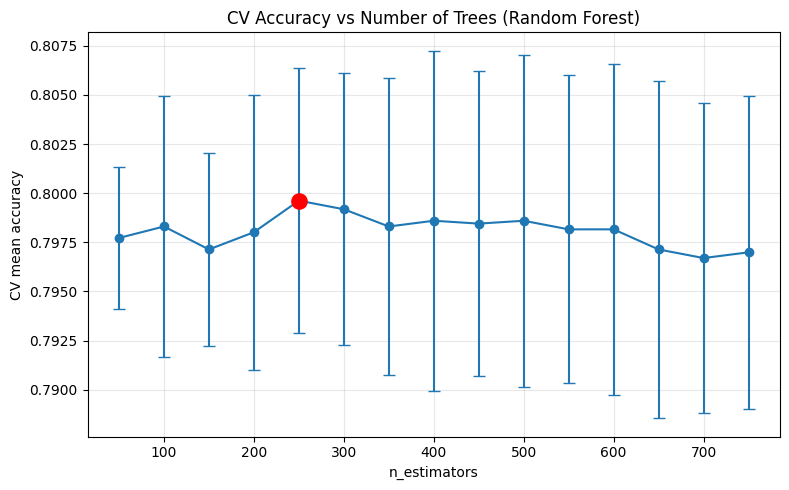

In [57]:
plt.figure(figsize=(8,5))

plt.errorbar(
    results_n["n_estimators"],
    results_n["cv_mean"],
    yerr=results_n["cv_std"],
    fmt="o-",
    capsize=4
)
best_idx = results_n["cv_mean"].idxmax()
best_n = results_n.loc[best_idx, "n_estimators"]
best_score = results_n.loc[best_idx, "cv_mean"]

plt.scatter(
    best_n,
    best_score,
    color="red",
    s=120,
    zorder=5,
    label=f"Best = {best_n}"
)


plt.title("CV Accuracy vs Number of Trees (Random Forest)")
plt.xlabel("n_estimators")
plt.ylabel("CV mean accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### best depth accuracy

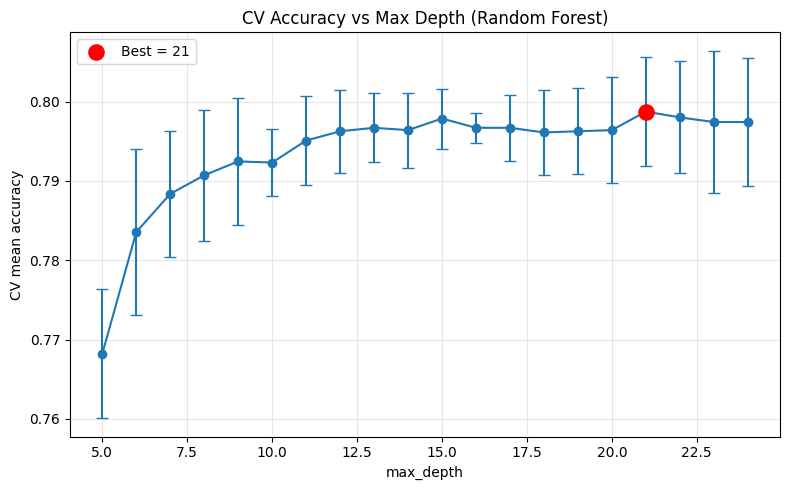

In [58]:
plt.figure(figsize=(8,5))

plt.errorbar(
    results_depth["max_depth"],
    results_depth["cv_mean"],
    yerr=results_depth["cv_std"],
    fmt="o-",
    capsize=4
)

best_idx = results_depth["cv_mean"].idxmax()
best_depth = results_depth.loc[best_idx, "max_depth"]
best_score = results_depth.loc[best_idx, "cv_mean"]

plt.scatter(
    best_depth,
    best_score,
    color="red",
    s=120,
    zorder=5,
    label=f"Best = {best_depth}"
)

plt.title("CV Accuracy vs Max Depth (Random Forest)")
plt.xlabel("max_depth")
plt.ylabel("CV mean accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



#### best max_features accuracy

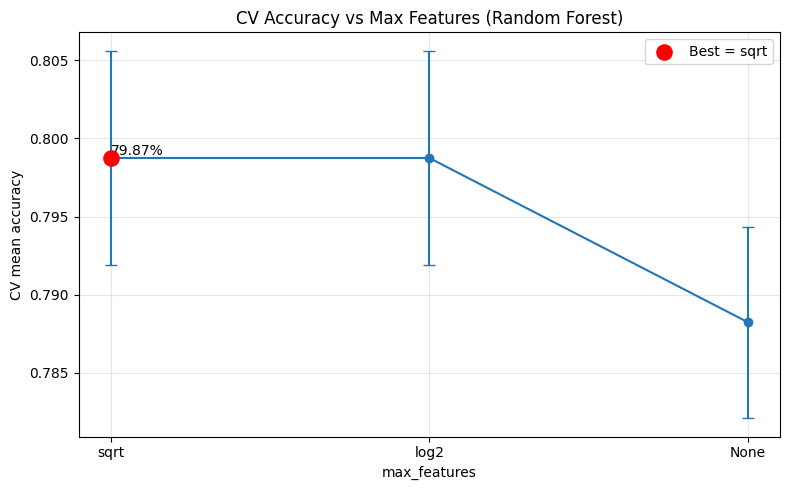

In [59]:
results_feat["max_features"] = results_feat["max_features"].astype(str)

plt.figure(figsize=(8,5))

# גרף
plt.errorbar(
    results_feat["max_features"],
    results_feat["cv_mean"],
    yerr=results_feat["cv_std"],
    fmt="o-",
    capsize=4
)

# נקודה הכי טובה
best_idx = results_feat["cv_mean"].idxmax()
best_feat = results_feat.loc[best_idx, "max_features"]
best_score = results_feat.loc[best_idx, "cv_mean"]

plt.scatter(
    best_feat,
    best_score,
    color="red",
    s=120,
    zorder=5,
    label=f"Best = {best_feat}"
)

# אחוז ליד הנקודה
plt.text(
    best_feat,
    best_score,
    f"{100*best_score:.2f}%",
    ha="left",
    va="bottom"
)

plt.title("CV Accuracy vs Max Features (Random Forest)")
plt.xlabel("max_features")
plt.ylabel("CV mean accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### best min_samples_leaf accuracy

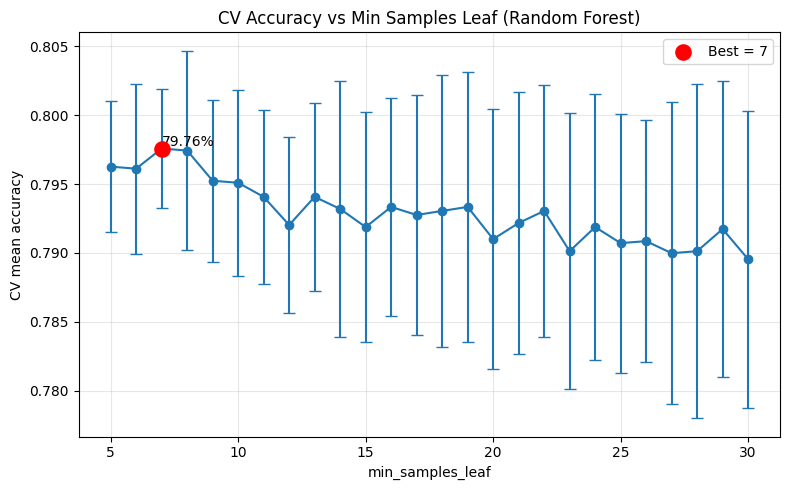

In [60]:
plt.figure(figsize=(8,5))

# גרף
plt.errorbar(
    results_leaf["min_samples_leaf"],
    results_leaf["cv_mean"],
    yerr=results_leaf["cv_std"],
    fmt="o-",
    capsize=4
)

# הנקודה הטובה ביותר
best_idx = results_leaf["cv_mean"].idxmax()
best_leaf = results_leaf.loc[best_idx, "min_samples_leaf"]
best_score = results_leaf.loc[best_idx, "cv_mean"]

plt.scatter(
    best_leaf,
    best_score,
    color="red",
    s=120,
    zorder=5,
    label=f"Best = {best_leaf}"
)

# אחוז ליד הנקודה
plt.text(
    best_leaf,
    best_score,
    f"{100*best_score:.2f}%",
    ha="left",
    va="bottom"
)

plt.title("CV Accuracy vs Min Samples Leaf (Random Forest)")
plt.xlabel("min_samples_leaf")
plt.ylabel("CV mean accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### best Random Forset accuracy

In [61]:
accuracy_train = best_RF.score(x_train, y_train)
print(f'Accuracy Train: {accuracy_train}')

Accuracy Train: 0.8761501387468964


#### Confusion matrix


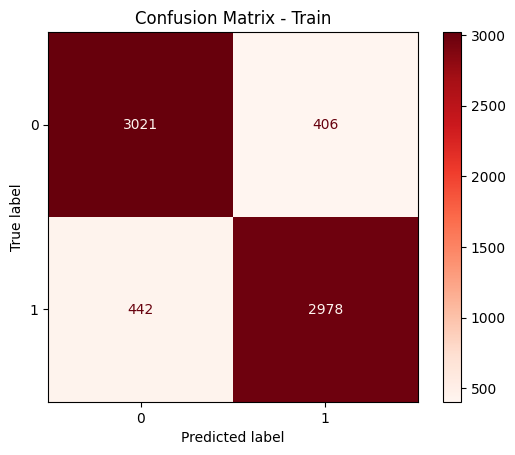

In [62]:
cm_train = confusion_matrix(y_train, best_RF.predict(x_train))

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Reds')
plt.title('Confusion Matrix - Train')
plt.show()



#### Random Forest Feature Importance  

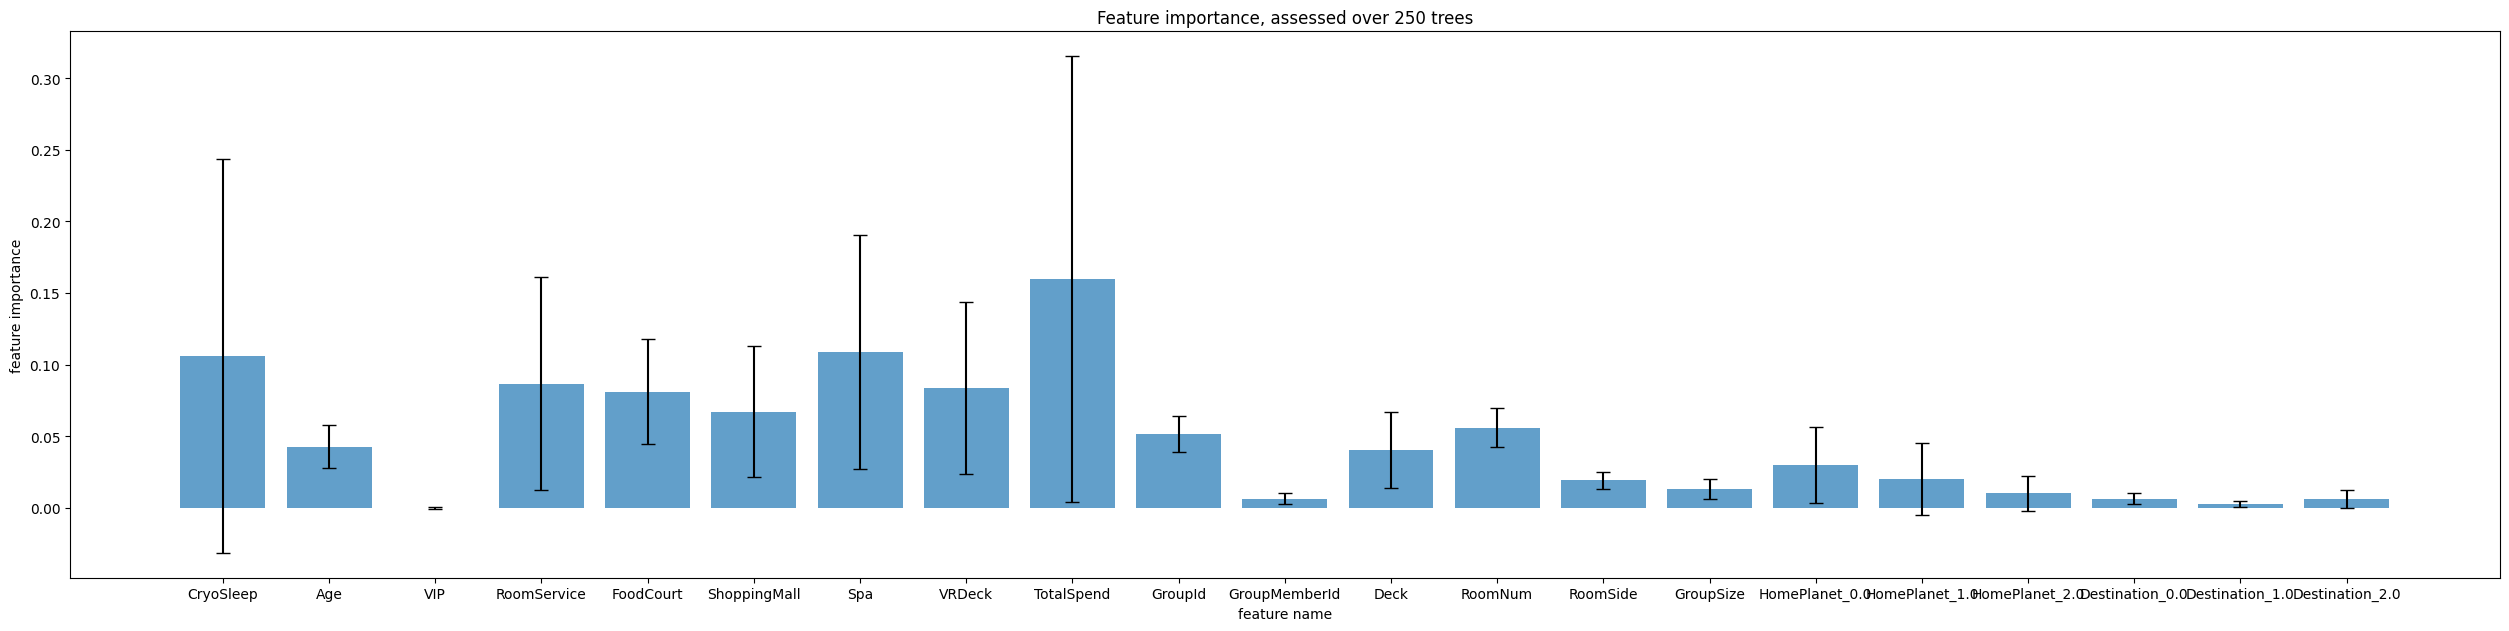

In [69]:
feature_importances = np.array([tree.feature_importances_ for tree in best_RF.estimators_])

feature_names = x_copy.columns.tolist()
mean_importance = feature_importances.mean(axis=0)
std_importance = feature_importances.std(axis=0)

positions = np.arange(feature_importances.shape[1])


plt.figure(figsize=(25, 6))
plt.bar(
    positions,
    mean_importance,
    yerr=std_importance,
    capsize=5,
    alpha=0.7
)

plt.xticks(positions, feature_names, rotation=0, ha="center")
plt.tight_layout()

plt.xlabel("feature name")
plt.ylabel("feature importance")
plt.title(f"Feature importance, assessed over {feature_importances.shape[0]} trees")
plt.show()

In [71]:
fi_per_tree = np.array([t.feature_importances_ for t in best_RF.estimators_])

fi_mean = fi_per_tree.mean(axis=0)
fi_std  = fi_per_tree.std(axis=0)

fi_df = pd.DataFrame({
    "feature": x_copy.columns,
    "importance_mean": fi_mean,
    "importance_std": fi_std
}).sort_values("importance_mean", ascending=False)

print("=== Feature Importances (Best Forest) ===")
display(fi_df)


=== Feature Importances (Best Forest) ===


,feature,importance_mean,importance_std
8,TotalSpend,0.159675,0.155606
6,Spa,0.108774,0.081476
0,CryoSleep,0.106330,0.137574
3,RoomService,0.086714,0.074475
7,VRDeck,0.083720,0.059717
4,FoodCourt,0.081182,0.036544
5,ShoppingMall,0.067302,0.045848
12,RoomNum,0.056153,0.013744
9,GroupId,0.051665,0.012372
1,Age,0.042697,0.015074


#### Summary Table

In [72]:
summary_df = pd.DataFrame([{
    "best_n_estimators": best_params_rf["n_estimators"],
    "best_max_depth": best_params_rf["max_depth"],
    "n_features": x_train.shape[1],
    "n_samples": x_train.shape[0]
}])

print("=== Best Forest Summary ===")
display(summary_df)

=== Best Forest Summary ===


,best_n_estimators,best_max_depth,n_features,n_samples
0,250,21,21,6847


#### Statistics 

In [73]:
tree_depths = np.array([t.tree_.max_depth for t in best_RF.estimators_])
tree_nodes  = np.array([t.tree_.node_count for t in best_RF.estimators_])
tree_leaves = np.array([t.tree_.n_leaves for t in best_RF.estimators_])

stats_df = pd.DataFrame({
    "metric": ["depth", "node_count", "n_leaves"],
    "mean":   [tree_depths.mean(), tree_nodes.mean(), tree_leaves.mean()],
    "std":    [tree_depths.std(),  tree_nodes.std(),  tree_leaves.std()],
    "min":    [tree_depths.min(),  tree_nodes.min(),  tree_leaves.min()],
    "max":    [tree_depths.max(),  tree_nodes.max(),  tree_leaves.max()],
})

print("=== Trees Statistics (actual) ===")
display(stats_df.round(2))

=== Trees Statistics (actual) ===


,metric,mean,std,min,max
0,depth,17.81,1.62,14,21
1,node_count,636.32,33.63,529,709
2,n_leaves,318.66,16.81,265,355


#### 

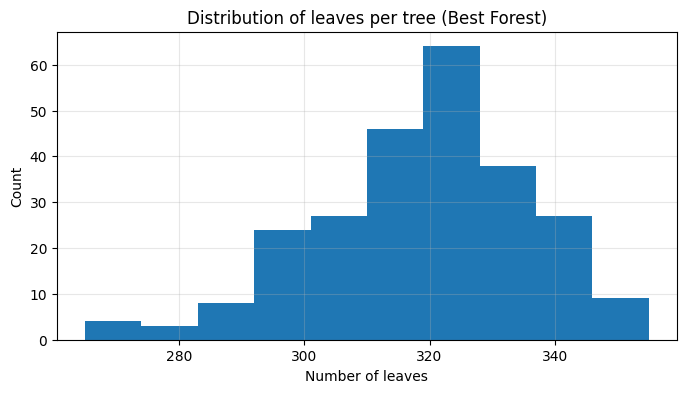

In [74]:
plt.figure(figsize=(8,4))
plt.hist(tree_leaves, bins=10)
plt.xlabel("Number of leaves")
plt.ylabel("Count")
plt.title("Distribution of leaves per tree (Best Forest)")
plt.grid(alpha=0.3)
plt.show()


In [75]:
acc = accuracy_score(y_train, y_pred_train)
prec = precision_score(y_train, y_pred_train)
rec = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)

metrics_df = pd.DataFrame([{
    "model": "RandomForest",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1
}])

display(metrics_df.round(4))

print("\nClassification Report (TRAIN):")
print(classification_report(y_train, y_pred_train))

,model,accuracy,precision,recall,f1_score
0,RandomForest,0.8762,0.88,0.8708,0.8754



Classification Report (TRAIN):
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      3427
           1       0.88      0.87      0.88      3420

    accuracy                           0.88      6847
   macro avg       0.88      0.88      0.88      6847
weighted avg       0.88      0.88      0.88      6847



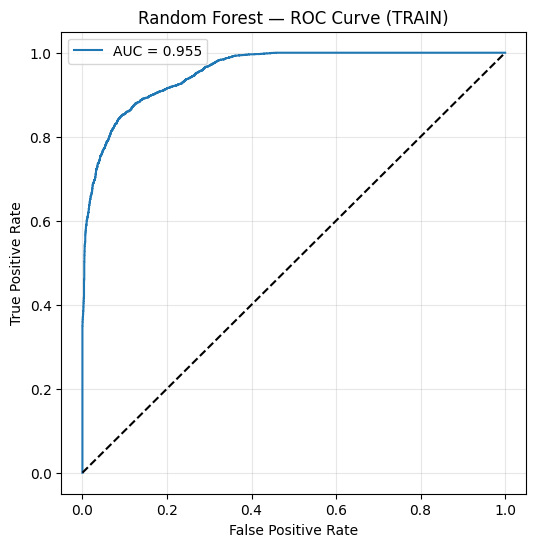

In [76]:
y_prob_train = best_RF.predict_proba(x_train)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, y_prob_train)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve (TRAIN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()